# Unit 11 Artefact 3: Testing Pineiro-Chousa et al.'s Options View of Reputational Risk

Ian Stevens, Security and Risk Management, Unit 11.

Pineiro-Chousa et al. (2017) treat corporate reputation as the underlying asset of an option and environmental management as the premium a company pays for it. A company that manages its environmental performance (an 'A-company') holds a long call (the chance to gain from reputational opportunities) and a long put (protection against reputational threats); a company that does not (a 'B-company') holds the opposite positions. The paper then argues how the positions change with the level of transparency and summarises the results in its Tables 1 and 2.

The paper is qualitative. It invokes the Black-Scholes model but never prices an option, so its tables are judgements about payoff shapes. This notebook prices the positions with Black-Scholes, using illustrative numbers, to see whether the judgements are internally consistent. Reputation is not a traded asset and cannot be hedged by trading, so Black-Scholes is used here only as a consistency check of the payoff claims, not as a way of valuing reputation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, lognorm

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#8a8984", "axes.labelcolor": "#0b0b0b",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e4e3df", "grid.linewidth": 0.8,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold", "lines.linewidth": 2,
})
BLUE, ORANGE, AQUA, VIOLET, INK, RED = "#2a78d6", "#eb6834", "#1baf7a", "#7c5cd6", "#52514e", "#c23b3b"

def bs(S, K, T, r, sig, kind):
    d1 = (np.log(S / K) + (r + sig**2 / 2) * T) / (sig * np.sqrt(T)); d2 = d1 - sig * np.sqrt(T)
    if kind == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

# Illustrative inputs: reputation index 100, one-year horizon, no discounting, 30% volatility.
S0, T, r, sig = 100.0, 1.0, 0.0, 0.30
K, Kp, Kc = 100.0, 90.0, 110.0   # one strike under information asymmetry; separate put and call strikes once good and bad practice are told apart

## 1. The premium rises with the market's valuation and its volatility

The paper says the effort demanded of an A-company is larger 'when the volatility observed in the market around that valuation increases'. This is the vega of an option and holds for any strike.

In [2]:
for s in (0.1, 0.2, 0.3, 0.5):
    print(f"volatility {s:.0%}: straddle premium {bs(S0, K, T, r, s, 'call') + bs(S0, K, T, r, s, 'put'):6.2f}")

volatility 10%: straddle premium   7.98
volatility 20%: straddle premium  15.93
volatility 30%: straddle premium  23.85
volatility 50%: straddle premium  39.48


## 2. From straddle to strangle: what voluntary disclosure changes

Under information asymmetry the A-company holds a long straddle (call and put at the same strike). With voluntary disclosure the market can tell good practice from bad, the call strike moves above the put strike, and the position becomes a long strangle. Table 1 of the paper says this lowers the premium from 'Low' to 'Very low', lowers the maximum loss from 'Low' to 'Very low' and raises the maximum reward from 'High' to 'Very high'.

In [3]:
P_straddle = bs(S0, K, T, r, sig, "call") + bs(S0, K, T, r, sig, "put")
P_strangle = bs(S0, Kc, T, r, sig, "call") + bs(S0, Kp, T, r, sig, "put")
S = np.linspace(0, 250, 2501)
profit_straddle = np.abs(S - K) - P_straddle
profit_strangle = np.maximum(S - Kc, 0) + np.maximum(Kp - S, 0) - P_strangle

dist = lognorm(s=sig * np.sqrt(T), scale=np.exp(np.log(S0) + (r - sig**2 / 2) * T))
def p_profit(lo, hi): return dist.cdf(lo) + 1 - dist.cdf(hi)
x = np.linspace(0.01, 1500, 600_001)
def expected(f): return np.trapezoid(f(x) * dist.pdf(x), x)

check = pd.DataFrame({
    "Long straddle (asymmetry)": [P_straddle, P_straddle, K - P_straddle, 200 - K - P_straddle,
        p_profit(K - P_straddle, K + P_straddle), expected(lambda s: np.abs(s - K) - P_straddle)],
    "Long strangle (voluntary disclosure)": [P_strangle, P_strangle, Kp - P_strangle, 200 - Kc - P_strangle,
        p_profit(Kp - P_strangle, Kc + P_strangle),
        expected(lambda s: np.maximum(s - Kc, 0) + np.maximum(Kp - s, 0) - P_strangle)],
}, index=["Premium (environmental effort)", "Maximum loss", "Profit if reputation collapses to 0",
          "Profit if reputation doubles to 200", "Probability of a positive result", "Expected result at a fair price"])
print(check.round(3).to_string())
lo, hi = S[profit_strangle > profit_straddle][[0, -1]]
print(f"\nThe strangle does better only between {lo:.1f} and {hi:.1f}, where both positions lose money.")

                                     Long straddle (asymmetry)  Long strangle (voluntary disclosure)
Premium (environmental effort)                          23.847                                15.154
Maximum loss                                            23.847                                15.154
Profit if reputation collapses to 0                     76.153                                74.846
Profit if reputation doubles to 200                     76.153                                74.846
Probability of a positive result                         0.418                                 0.392
Expected result at a fair price                          0.000                                 0.000

The strangle does better only between 91.4 and 108.6, where both positions lose money.


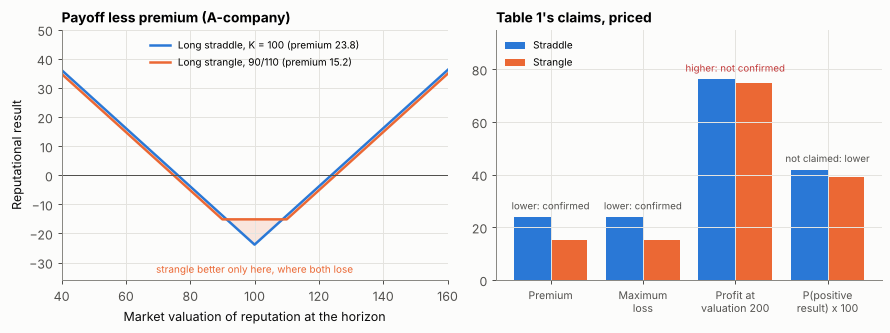

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
ax[0].plot(S, profit_straddle, color=BLUE, label=f"Long straddle, K = {K:.0f} (premium {P_straddle:.1f})")
ax[0].plot(S, profit_strangle, color=ORANGE, label=f"Long strangle, {Kp:.0f}/{Kc:.0f} (premium {P_strangle:.1f})")
ax[0].axhline(0, color=INK, lw=0.8)
ax[0].fill_between(S, profit_straddle, profit_strangle, where=profit_strangle > profit_straddle, color=ORANGE, alpha=0.15, lw=0)
ax[0].set_xlim(40, 160); ax[0].set_ylim(-36, 50)
ax[0].set_xlabel("Market valuation of reputation at the horizon"); ax[0].set_ylabel("Reputational result")
ax[0].set_title("Payoff less premium (A-company)", loc="left")
ax[0].legend(frameon=False, fontsize=8, loc="upper center")
ax[0].text(100, -33.5, "strangle better only here, where both lose", ha="center", fontsize=8, color=ORANGE)
names = ["Premium", "Maximum\nloss", "Profit at\nvaluation 200", "P(positive\nresult) x 100"]
a = [P_straddle, P_straddle, 200 - K - P_straddle, 100 * check.iloc[4, 0]]
b = [P_strangle, P_strangle, 200 - Kc - P_strangle, 100 * check.iloc[4, 1]]
xx = np.arange(4)
ax[1].bar(xx - 0.2, a, 0.4, color=BLUE, label="Straddle"); ax[1].bar(xx + 0.2, b, 0.4, color=ORANGE, label="Strangle")
claims = ["lower: confirmed", "lower: confirmed", "higher: not confirmed", "not claimed: lower"]
for i, c in enumerate(claims):
    ax[1].text(i, max(a[i], b[i]) + 3, c, ha="center", fontsize=7.8, color=RED if "not confirmed" in c else INK)
ax[1].set_xticks(xx, names, fontsize=8.5); ax[1].set_ylim(0, 95)
ax[1].set_title("Table 1's claims, priced", loc="left"); ax[1].legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig("figures/u11_options.png", dpi=150, bbox_inches="tight")

Two of the three claims hold: the strangle is cheaper and its maximum loss (the premium) is smaller. The third does not. In both tails the strangle earns less than the straddle, because its strikes are further away, and the premium it saves is smaller than the extra distance. It also has a lower chance of ending in profit. At a fair price both positions have an expected result of zero, as any fairly priced option must.

This is not a quirk of the chosen numbers. With the strikes moved apart by the same amount on each side, the premium saved can never exceed the distance the strikes have moved, so the strangle earns less in the tails at any volatility (checked below). More generally, a cheaper option position on the same asset must pay less somewhere, or there would be a free profit. If voluntary disclosure really lowers the cost of environmental management and raises the reward, as the paper concludes, the gain must come from the market valuing the A-company's reputation differently (a change in the underlying asset), not from the change in option structure. The paper's real argument is about information, and the option framing does not add to it.

In [5]:
for s in (0.05, 0.1, 0.2, 0.3, 0.5, 1.0, 2.0):
    saved = (bs(S0, K, T, r, s, "call") + bs(S0, K, T, r, s, "put")) - (bs(S0, Kc, T, r, s, "call") + bs(S0, Kp, T, r, s, "put"))
    print(f"volatility {s:4.0%}: premium saved {saved:5.2f} against strikes moved {Kc - K:.0f}; change in tail profit {saved - (Kc - K):6.2f}")

volatility   5%: premium saved  3.90 against strikes moved 10; change in tail profit  -6.10
volatility  10%: premium saved  6.31 against strikes moved 10; change in tail profit  -3.69
volatility  20%: premium saved  8.05 against strikes moved 10; change in tail profit  -1.95
volatility  30%: premium saved  8.69 against strikes moved 10; change in tail profit  -1.31
volatility  50%: premium saved  9.23 against strikes moved 10; change in tail profit  -0.77
volatility 100%: premium saved  9.65 against strikes moved 10; change in tail profit  -0.35
volatility 200%: premium saved  9.88 against strikes moved 10; change in tail profit  -0.12


## 3. Mandatory reporting: the B-company's positions

With mandatory reporting the B-company buys assurance (a long put) while still wasting reputational opportunities (a short call): a 'short combo'. Table 2 says its net effort is 'around zero'. When reporting matures and the strikes coincide, the position becomes a short synthetic future.

In [6]:
for kp, kc in [(90, 110), (95, 105), (80, 120), (100, 100)]:
    net = bs(S0, kp, T, r, sig, "put") - bs(S0, kc, T, r, sig, "call")
    print(f"put strike {kp:3d}, call strike {kc:3d}: net premium paid by B-company {net:6.2f}")
print("\nPut-call parity at a single strike: P - C = K*exp(-rT) - S0 =", round(K * np.exp(-r * T) - S0, 6))

put strike  90, call strike 110: net premium paid by B-company  -1.13
put strike  95, call strike 105: net premium paid by B-company  -0.59
put strike  80, call strike 120: net premium paid by B-company  -1.91
put strike 100, call strike 100: net premium paid by B-company   0.00

Put-call parity at a single strike: P - C = K*exp(-rT) - S0 = 0.0


The net premium is small and can be negative, so 'around zero' is fair for these inputs, and at a single strike put-call parity makes it exactly zero when the strike equals the forward value. These parts of the tables are consistent.

## 4. What the framing assumes

* **Reputation is zero-sum.** The B-company's result is defined as the mirror image of the A-company's. That is a modelling choice, not a finding. A sector-wide scandal can lower every company's reputation together, and the paper offers no evidence that reputation moves from one company to another.
* **The assurer bears the bad reputation.** The text calls the counterparty 'assurance companies' and Figure 6 labels it 'Insurance'. Assurance under standards such as ISAE 3000 is an opinion on reported information. If a company's reported performance turns out to be false, its customers and investors judge the company; the assurer may share some liability and lose reputation of its own, but it does not take over the company's loss.
* **Prices exist.** Black-Scholes needs a traded underlying, a known volatility and continuous hedging. None exists for reputation, which is why the paper can only describe the shape of each position.

The useful idea that survives is the asymmetry. Preparation is a premium paid before an event, its value rises with the volatility of reputation, and it pays off only if the event happens and the company can show what it did.